# 🔧 Notebook 4: Optimización de Hiperparámetros

## TFM: Predicción de Estrategias de Carrera en Fórmula 1 mediante ML

**Autor:** Francisco José Moreno Bayona  
**Universidad:** UNIR  

---

### Objetivo

Optimizar los hiperparámetros de los 5 modelos entrenados en el Notebook 3,
usando **RandomizedSearchCV** con **TimeSeriesSplit** para respetar el orden temporal.

### Resultados baseline (Notebook 3)

| Modelo | F1 (clasif.) | RMSE (regres.) |
|--------|-------------|----------------|
| MLP | 0.7111 | 8.658 |
| Random Forest | 0.7006 | 8.387 |
| XGBoost | 0.6874 | 8.542 |
| LightGBM | 0.6558 | 8.437 |
| Decision Tree | 0.5462 | 8.792 |

### Estrategia
1. Definir grids amplios de hiperparámetros
2. RandomizedSearchCV con TimeSeriesSplit (3 folds temporales)
3. Evaluar mejora respecto a baseline
4. Reentrenar con los mejores hiperparámetros sobre todo el train
5. Evaluación final en test

## 1. Imports y carga de datos

In [1]:
import subprocess, sys
for p in ['optuna', 'xgboost', 'lightgbm']:
    try: __import__(p)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', p, '-q'])
        print(f'✓ {p} instalado')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, pickle
from pathlib import Path

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score,
    make_scorer
)
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform, loguniform

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Imports completados')

C:\Users\franm\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports completados


In [2]:
# ============================================================================
# CARGAR DATOS (mismos que Notebook 3)
# ============================================================================

train_c = pd.read_csv('./datasets/prepared/train_clasificacion.csv')
test_c = pd.read_csv('./datasets/prepared/test_clasificacion.csv')

try:
    train_r = pd.read_csv('./datasets/prepared/train_regresion_v2.csv')
    test_r = pd.read_csv('./datasets/prepared/test_regresion_v2.csv')
except FileNotFoundError:
    df_reg = pd.read_csv('./datasets/dataset_regresion_v2.csv')
    df_reg = df_reg.sort_values('EventDate').reset_index(drop=True)
    n = int(len(df_reg) * 0.8)
    train_r, test_r = df_reg.iloc[:n], df_reg.iloc[n:]

FEATURES = [
    'LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber',
    'IsHard', 'IsMedium', 'IsSoft',
    'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator',
]
features_clasif = [f for f in FEATURES if f in train_c.columns]
features_regres = [f for f in FEATURES if f in train_r.columns]

X_train_c = train_c[features_clasif]
y_train_c = train_c['target_parada']
X_test_c = test_c[features_clasif]
y_test_c = test_c['target_parada']

TARGET_REG = 'LapsUntilNextStop' if 'LapsUntilNextStop' in train_r.columns else 'target_vuelta_parada'
X_train_r = train_r[features_regres]
y_train_r = train_r[TARGET_REG]
X_test_r = test_r[features_regres]
y_test_r = test_r[TARGET_REG]

# Normalizado para MLP regresión
scaler_r = StandardScaler()
features_num = [f for f in features_regres if f not in ['IsHard', 'IsMedium', 'IsSoft']]
X_train_r_norm = X_train_r.copy()
X_test_r_norm = X_test_r.copy()
X_train_r_norm[features_num] = scaler_r.fit_transform(X_train_r[features_num])
X_test_r_norm[features_num] = scaler_r.transform(X_test_r[features_num])

n_neg = (y_train_c == 0).sum()
n_pos = (y_train_c == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f'Clasificación: {X_train_c.shape} train, {X_test_c.shape} test')
print(f'Regresión: {X_train_r.shape} train, {X_test_r.shape} test')
print(f'Scale pos weight: {scale_pos_weight:.1f}')

Clasificación: (74392, 11) train, (18599, 11) test
Regresión: (42691, 11) train, (10673, 11) test
Scale pos weight: 29.9


## 2. Configuración de la validación cruzada temporal

**¿Por qué TimeSeriesSplit y no KFold?**

Nuestros datos son temporales (carreras ordenadas por fecha).
KFold mezclaría datos futuros en el entrenamiento, lo que sería data leakage.
TimeSeriesSplit respeta el orden: cada fold entrena con datos anteriores
y valida con datos posteriores, simulando predicción real.

```
Fold 1: Train [====]     Val [==]
Fold 2: Train [======]   Val [==]
Fold 3: Train [========] Val [==]
```

In [3]:
# ============================================================================
# VALIDACIÓN CRUZADA TEMPORAL
# ============================================================================

# DECISIÓN: 3 folds temporales
# Más folds = más robusto pero más lento
# 3 es un buen balance para datasets de este tamaño
tscv = TimeSeriesSplit(n_splits=3)

# Scorer para clasificación: F1 (nuestra métrica principal)
scorer_f1 = make_scorer(f1_score)

# Scorer para regresión: RMSE negativo (sklearn minimiza, necesitamos neg)
scorer_rmse = make_scorer(mean_squared_error, greater_is_better=False, squared=False)

# Número de combinaciones a probar por modelo
N_ITER = 200  # Aumentar a 100-200 si tienes tiempo

print(f'TimeSeriesSplit: {tscv.get_n_splits()} folds')
print(f'Iteraciones por modelo: {N_ITER}')
print(f'Scorer clasificación: F1-score')
print(f'Scorer regresión: neg_RMSE')

TimeSeriesSplit: 3 folds
Iteraciones por modelo: 200
Scorer clasificación: F1-score
Scorer regresión: neg_RMSE


## 3. Definición de espacios de búsqueda

Cada modelo tiene hiperparámetros distintos. Los rangos se eligen
basándose en buenas prácticas y en los valores por defecto como punto central.

In [4]:
# ============================================================================
# ESPACIOS DE BÚSQUEDA — CLASIFICACIÓN
# ============================================================================

param_grids_clasif = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        'params': {
            'max_depth': randint(3, 25),
            'min_samples_split': randint(2, 50),
            'min_samples_leaf': randint(1, 30),
            'max_features': ['sqrt', 'log2', None],
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
        'params': {
            'n_estimators': randint(100, 500),
            'max_depth': randint(5, 30),
            'min_samples_split': randint(2, 20),
            'min_samples_leaf': randint(1, 15),
            'max_features': ['sqrt', 'log2', None],
        }
    },
    'XGBoost': {
        'model': XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=RANDOM_STATE),
        'params': {
            'n_estimators': randint(100, 600),
            'max_depth': randint(3, 15),
            'learning_rate': loguniform(0.01, 0.3),
            'subsample': uniform(0.6, 0.4),
            'colsample_bytree': uniform(0.6, 0.4),
            'min_child_weight': randint(1, 10),
            'gamma': uniform(0, 0.5),
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(is_unbalance=True, verbose=-1, random_state=RANDOM_STATE),
        'params': {
            'n_estimators': randint(100, 600),
            'max_depth': randint(3, 15),
            'learning_rate': loguniform(0.01, 0.3),
            'num_leaves': randint(15, 100),
            'subsample': uniform(0.6, 0.4),
            'colsample_bytree': uniform(0.6, 0.4),
            'min_child_samples': randint(5, 50),
        }
    },
    'MLP': {
        'model': MLPClassifier(early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE),
        'params': {
            'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32), (256, 128, 64), (256, 128, 64, 32)],
            'activation': ['relu', 'tanh'],
            'learning_rate_init': loguniform(0.0005, 0.01),
            'alpha': loguniform(0.0001, 0.01),
            'max_iter': [300, 500],
        }
    },
}

print('Espacios de búsqueda definidos para CLASIFICACIÓN:')
for nombre, config in param_grids_clasif.items():
    print(f'  {nombre}: {len(config["params"])} hiperparámetros')

Espacios de búsqueda definidos para CLASIFICACIÓN:
  Decision Tree: 4 hiperparámetros
  Random Forest: 5 hiperparámetros
  XGBoost: 7 hiperparámetros
  LightGBM: 7 hiperparámetros
  MLP: 5 hiperparámetros


In [5]:
# ============================================================================
# ESPACIOS DE BÚSQUEDA — REGRESIÓN
# ============================================================================

param_grids_regres = {
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=RANDOM_STATE),
        'params': {
            'max_depth': randint(3, 25),
            'min_samples_split': randint(2, 50),
            'min_samples_leaf': randint(1, 30),
            'max_features': ['sqrt', 'log2', None],
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
        'params': {
            'n_estimators': randint(100, 500),
            'max_depth': randint(5, 30),
            'min_samples_split': randint(2, 20),
            'min_samples_leaf': randint(1, 15),
            'max_features': ['sqrt', 'log2', None],
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=RANDOM_STATE),
        'params': {
            'n_estimators': randint(100, 600),
            'max_depth': randint(3, 15),
            'learning_rate': loguniform(0.01, 0.3),
            'subsample': uniform(0.6, 0.4),
            'colsample_bytree': uniform(0.6, 0.4),
            'min_child_weight': randint(1, 10),
        }
    },
    'LightGBM': {
        'model': LGBMRegressor(verbose=-1, random_state=RANDOM_STATE),
        'params': {
            'n_estimators': randint(100, 600),
            'max_depth': randint(3, 15),
            'learning_rate': loguniform(0.01, 0.3),
            'num_leaves': randint(15, 100),
            'subsample': uniform(0.6, 0.4),
            'colsample_bytree': uniform(0.6, 0.4),
        }
    },
    'MLP': {
        'model': MLPRegressor(early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE),
        'params': {
            'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32), (256, 128, 64), (256, 128, 64, 32)],
            'activation': ['relu', 'tanh'],
            'learning_rate_init': loguniform(0.0005, 0.01),
            'alpha': loguniform(0.0001, 0.01),
            'max_iter': [300, 500],
        }
    },
}

print('Espacios de búsqueda definidos para REGRESIÓN:')
for nombre, config in param_grids_regres.items():
    print(f'  {nombre}: {len(config["params"])} hiperparámetros')

Espacios de búsqueda definidos para REGRESIÓN:
  Decision Tree: 4 hiperparámetros
  Random Forest: 5 hiperparámetros
  XGBoost: 6 hiperparámetros
  LightGBM: 6 hiperparámetros
  MLP: 5 hiperparámetros


---
# PARTE A: Optimización — Clasificación
---

## 4. Búsqueda de hiperparámetros (clasificación)

⏱️ **Tiempo estimado: 10-30 minutos** (dependiendo de tu hardware)

In [6]:
# ============================================================================
# RANDOMIZED SEARCH — CLASIFICACIÓN
# ============================================================================

mejores_clasif = {}

for nombre, config in param_grids_clasif.items():
    print(f'\n{"="*60}')
    print(f'Optimizando: {nombre}')
    print(f'{"="*60}')
    
    inicio = time.time()
    
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=N_ITER,
        cv=tscv,
        scoring=scorer_f1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        return_train_score=True
    )
    
    search.fit(X_train_c, y_train_c)
    duracion = time.time() - inicio
    
    mejores_clasif[nombre] = {
        'best_params': search.best_params_,
        'best_cv_score': search.best_score_,
        'best_model': search.best_estimator_,
        'search_time': duracion
    }
    
    print(f'  Mejor F1 (CV): {search.best_score_:.4f}')
    print(f'  Tiempo: {duracion:.1f}s')
    print(f'  Mejores hiperparámetros:')
    for param, valor in search.best_params_.items():
        print(f'    {param}: {valor}')

print('\n✅ Optimización de clasificación completada')


Optimizando: Decision Tree
  Mejor F1 (CV): 0.6231
  Tiempo: 36.4s
  Mejores hiperparámetros:
    max_depth: 17
    max_features: None
    min_samples_leaf: 1
    min_samples_split: 4

Optimizando: Random Forest
  Mejor F1 (CV): 0.7060
  Tiempo: 17223.7s
  Mejores hiperparámetros:
    max_depth: 24
    max_features: log2
    min_samples_leaf: 3
    min_samples_split: 2
    n_estimators: 278

Optimizando: XGBoost
  Mejor F1 (CV): 0.7031
  Tiempo: 427.3s
  Mejores hiperparámetros:
    colsample_bytree: 0.8843809915346993
    gamma: 0.09975346366915988
    learning_rate: 0.12232813758722677
    max_depth: 14
    min_child_weight: 1
    n_estimators: 189
    subsample: 0.9071118005771355

Optimizando: LightGBM
  Mejor F1 (CV): 0.6981
  Tiempo: 605.9s
  Mejores hiperparámetros:
    colsample_bytree: 0.9043140194467589
    learning_rate: 0.06746437142284309
    max_depth: 9
    min_child_samples: 31
    n_estimators: 492
    num_leaves: 93
    subsample: 0.7710164073434198

Optimizando: MLP

### 4.1 Evaluación final en test (clasificación optimizada)

In [7]:
# ============================================================================
# EVALUACIÓN FINAL EN TEST — CLASIFICACIÓN
# ============================================================================

resultados_opt_clasif = {}

# Baselines del Notebook 3
baselines_clasif = {
    'MLP': 0.7111, 'Random Forest': 0.7006, 'XGBoost': 0.6874,
    'LightGBM': 0.6558, 'Decision Tree': 0.5462
}

for nombre, info in mejores_clasif.items():
    modelo = info['best_model']
    y_pred = modelo.predict(X_test_c)
    y_proba = modelo.predict_proba(X_test_c)[:, 1] if hasattr(modelo, 'predict_proba') else y_pred.astype(float)
    
    f1 = f1_score(y_test_c, y_pred)
    precision = precision_score(y_test_c, y_pred, zero_division=0)
    recall = recall_score(y_test_c, y_pred)
    roc_auc = roc_auc_score(y_test_c, y_proba)
    baseline = baselines_clasif.get(nombre, 0)
    mejora = f1 - baseline
    
    resultados_opt_clasif[nombre] = {
        'F1 baseline': baseline,
        'F1 optimizado': f1,
        'Mejora': mejora,
        'Precision': precision,
        'Recall': recall,
        'ROC-AUC': roc_auc,
    }
    
    emoji = '📈' if mejora > 0 else '📉'
    print(f'{emoji} {nombre:20s}  F1: {baseline:.4f} → {f1:.4f} ({mejora:+.4f})')

print()
df_opt_c = pd.DataFrame(resultados_opt_clasif).T.sort_values('F1 optimizado', ascending=False)
display(df_opt_c.round(4))

📈 Decision Tree         F1: 0.5462 → 0.6438 (+0.0976)
📉 Random Forest         F1: 0.7006 → 0.6825 (-0.0181)
📉 XGBoost               F1: 0.6874 → 0.6873 (-0.0001)
📈 LightGBM              F1: 0.6558 → 0.6787 (+0.0229)
📉 MLP                   F1: 0.7111 → 0.6958 (-0.0153)



,F1 baseline,F1 optimizado,Mejora,Precision,Recall,ROC-AUC
MLP,0.7111,0.6958,-0.0153,0.7990,0.6162,0.9759
XGBoost,0.6874,0.6873,-0.0001,0.6610,0.7159,0.9798
Random Forest,0.7006,0.6825,-0.0181,0.6537,0.7140,0.9789
LightGBM,0.6558,0.6787,0.0229,0.6350,0.7288,0.9696
Decision Tree,0.5462,0.6438,0.0976,0.5574,0.7620,0.8733


### 4.2 Comparativa baseline vs. optimizado (clasificación)

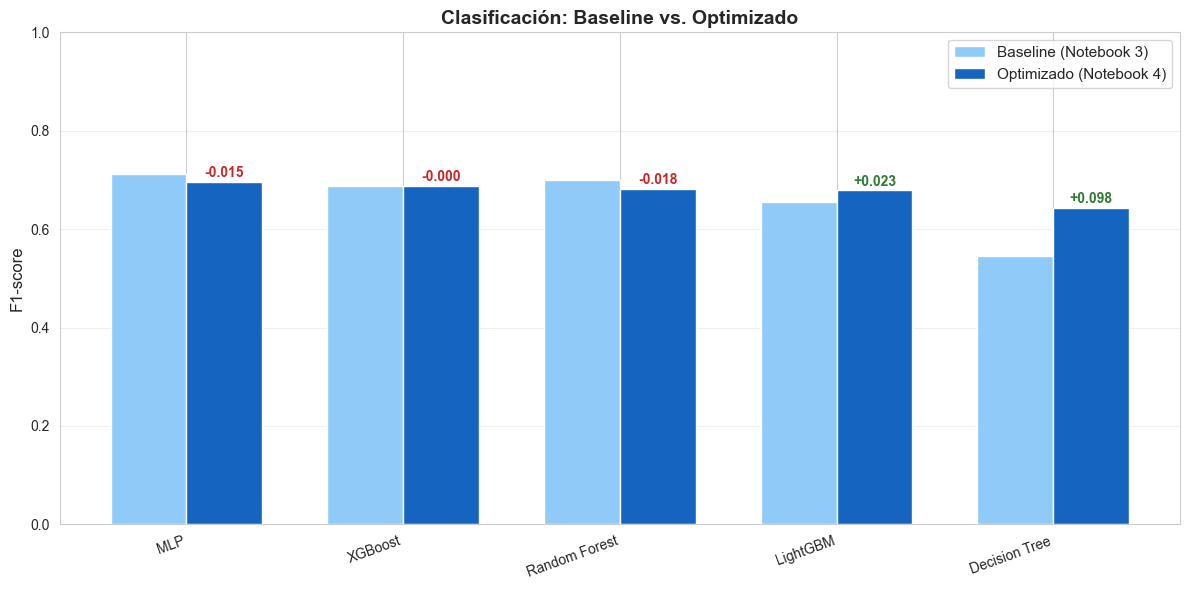

In [8]:
# ============================================================================
# GRÁFICO: BASELINE vs OPTIMIZADO
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

modelos_nombres = df_opt_c.index.tolist()
x = np.arange(len(modelos_nombres))
width = 0.35

bars1 = ax.bar(x - width/2, df_opt_c['F1 baseline'], width, label='Baseline (Notebook 3)',
               color='#90CAF9', edgecolor='white')
bars2 = ax.bar(x + width/2, df_opt_c['F1 optimizado'], width, label='Optimizado (Notebook 4)',
               color='#1565C0', edgecolor='white')

# Etiquetas de mejora
for i, (b, o, m) in enumerate(zip(df_opt_c['F1 baseline'], df_opt_c['F1 optimizado'], df_opt_c['Mejora'])):
    color = '#2E7D32' if m > 0 else '#C62828'
    ax.text(i + width/2, o + 0.01, f'{m:+.3f}', ha='center', fontsize=10,
            fontweight='bold', color=color)

ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('Clasificación: Baseline vs. Optimizado', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos_nombres, rotation=20, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./datasets/prepared/fig_baseline_vs_optimizado_clasif.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Matrices de confusión (modelos optimizados)

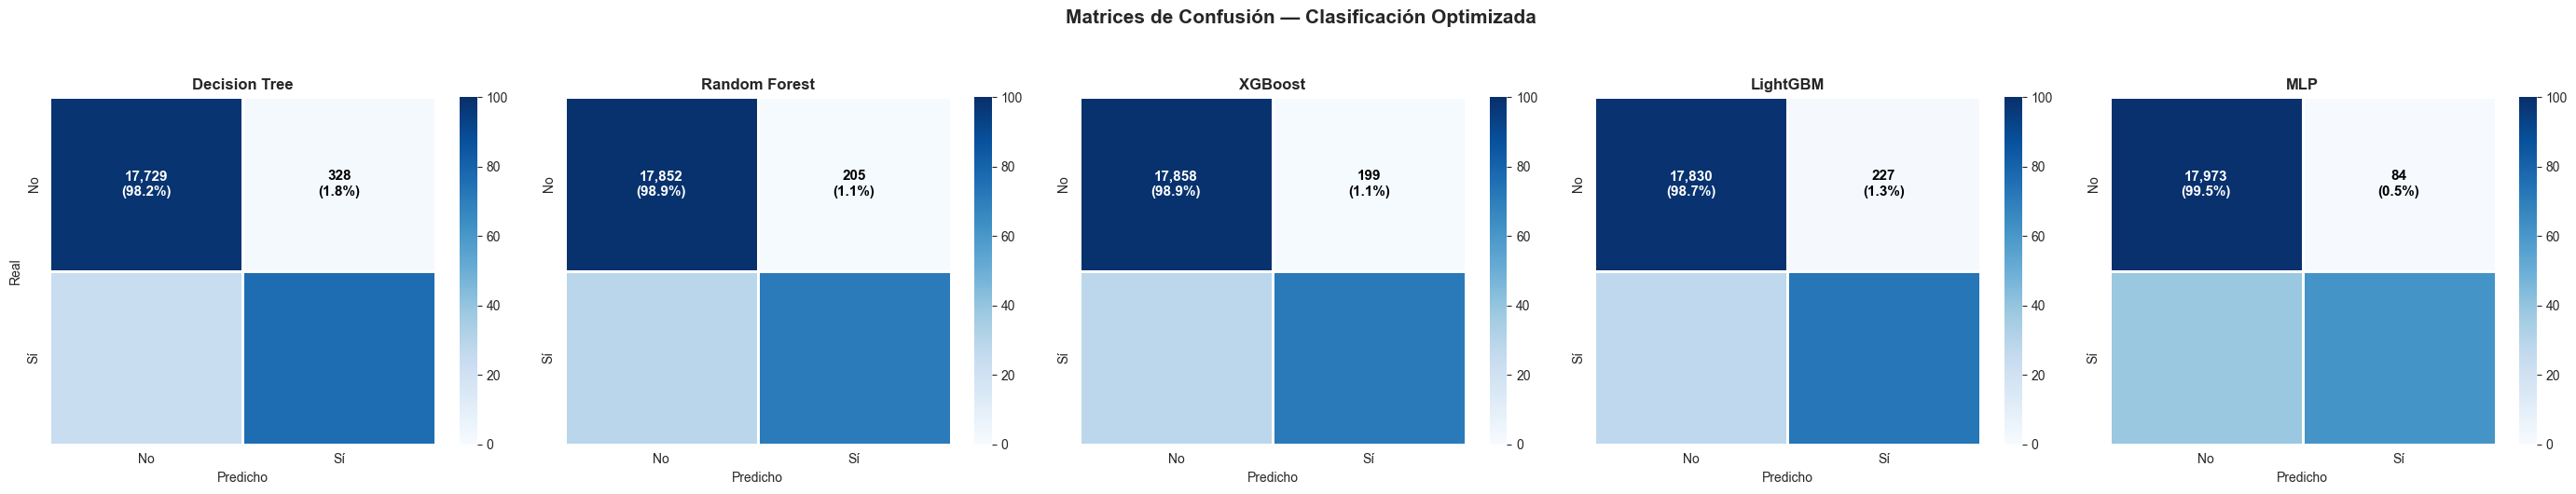

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

for idx, (nombre, info) in enumerate(mejores_clasif.items()):
    modelo = info['best_model']
    y_pred = modelo.predict(X_test_c)
    cm = confusion_matrix(y_test_c, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    
    labels = np.array([
        [f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)' for j in range(2)]
        for i in range(2)
    ])
    
    sns.heatmap(cm_pct, annot=labels, fmt='', cmap='Blues', ax=axes[idx],
                xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'],
                vmin=0, vmax=100,
                annot_kws={'fontsize': 11, 'fontweight': 'bold'},
                linewidths=2, linecolor='white')
    
    for text_obj in axes[idx].texts:
        x, y = text_obj.get_position()
        valor = cm_pct[int(y), int(x)]
        text_obj.set_color('white' if valor > 50 else 'black')
    
    axes[idx].set_title(nombre, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicho')
    if idx == 0:
        axes[idx].set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Clasificación Optimizada', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('./datasets/prepared/fig_confusion_optimizado.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTE B: Optimización — Regresión
---

## 5. Búsqueda de hiperparámetros (regresión)

⏱️ **Tiempo estimado: 15-40 minutos**

In [10]:
# ============================================================================
# RANDOMIZED SEARCH — REGRESIÓN
# ============================================================================

mejores_regres = {}

for nombre, config in param_grids_regres.items():
    print(f'\n{"="*60}')
    print(f'Optimizando: {nombre}')
    print(f'{"="*60}')
    
    inicio = time.time()
    
    # MLP necesita datos normalizados
    X_tr = X_train_r_norm if nombre == 'MLP' else X_train_r
    
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=N_ITER,
        cv=tscv,
        scoring=scorer_rmse,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        return_train_score=True
    )
    
    search.fit(X_tr, y_train_r)
    duracion = time.time() - inicio
    
    mejores_regres[nombre] = {
        'best_params': search.best_params_,
        'best_cv_score': -search.best_score_,  # Revertir signo negativo
        'best_model': search.best_estimator_,
        'search_time': duracion
    }
    
    print(f'  Mejor RMSE (CV): {-search.best_score_:.4f}')
    print(f'  Tiempo: {duracion:.1f}s')
    print(f'  Mejores hiperparámetros:')
    for param, valor in search.best_params_.items():
        print(f'    {param}: {valor}')

print('\n✅ Optimización de regresión completada')


Optimizando: Decision Tree
  Mejor RMSE (CV): 7.8969
  Tiempo: 10.2s
  Mejores hiperparámetros:
    max_depth: 7
    max_features: None
    min_samples_leaf: 19
    min_samples_split: 21

Optimizando: Random Forest
  Mejor RMSE (CV): 7.5417
  Tiempo: 2319.2s
  Mejores hiperparámetros:
    max_depth: 9
    max_features: log2
    min_samples_leaf: 6
    min_samples_split: 12
    n_estimators: 339

Optimizando: XGBoost
  Mejor RMSE (CV): 7.5616
  Tiempo: 634.6s
  Mejores hiperparámetros:
    colsample_bytree: 0.708383057006052
    learning_rate: 0.015730067247643295
    max_depth: 5
    min_child_weight: 6
    n_estimators: 181
    subsample: 0.7666556230953917

Optimizando: LightGBM
  Mejor RMSE (CV): 7.5657
  Tiempo: 391.1s
  Mejores hiperparámetros:
    colsample_bytree: 0.8363333042276043
    learning_rate: 0.011093090790700134
    max_depth: 6
    n_estimators: 269
    num_leaves: 84
    subsample: 0.7213062058692892

Optimizando: MLP
  Mejor RMSE (CV): 7.9888
  Tiempo: 23130.3s
  M

### 5.1 Evaluación final en test (regresión optimizada)

In [11]:
# ============================================================================
# EVALUACIÓN FINAL EN TEST — REGRESIÓN
# ============================================================================

resultados_opt_regres = {}

baselines_regres = {
    'Random Forest': 8.387, 'LightGBM': 8.437, 'XGBoost': 8.542,
    'MLP': 8.658, 'Decision Tree': 8.792
}

for nombre, info in mejores_regres.items():
    modelo = info['best_model']
    X_te = X_test_r_norm if nombre == 'MLP' else X_test_r
    y_pred = modelo.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae = mean_absolute_error(y_test_r, y_pred)
    r2 = r2_score(y_test_r, y_pred)
    baseline = baselines_regres.get(nombre, 99)
    mejora = baseline - rmse  # Positivo = mejora
    
    resultados_opt_regres[nombre] = {
        'RMSE baseline': baseline,
        'RMSE optimizado': rmse,
        'Mejora RMSE': mejora,
        'MAE': mae,
        'R²': r2,
    }
    
    emoji = '📈' if mejora > 0 else '📉'
    print(f'{emoji} {nombre:20s}  RMSE: {baseline:.3f} → {rmse:.3f} ({mejora:+.3f})')

print()
df_opt_r = pd.DataFrame(resultados_opt_regres).T.sort_values('RMSE optimizado')
display(df_opt_r.round(4))

📈 Decision Tree         RMSE: 8.792 → 8.540 (+0.252)
📈 Random Forest         RMSE: 8.387 → 8.290 (+0.097)
📈 XGBoost               RMSE: 8.542 → 8.363 (+0.179)
📈 LightGBM              RMSE: 8.437 → 8.284 (+0.153)
📉 MLP                   RMSE: 8.658 → 8.692 (-0.034)



,RMSE baseline,RMSE optimizado,Mejora RMSE,MAE,R²
LightGBM,8.437,8.2837,0.1533,6.1480,0.3585
Random Forest,8.387,8.2899,0.0971,6.1701,0.3575
XGBoost,8.542,8.3635,0.1785,6.2535,0.3460
Decision Tree,8.792,8.5400,0.2520,6.3251,0.3181
MLP,8.658,8.6917,-0.0337,6.3109,0.2937


### 5.2 Comparativa baseline vs. optimizado (regresión)

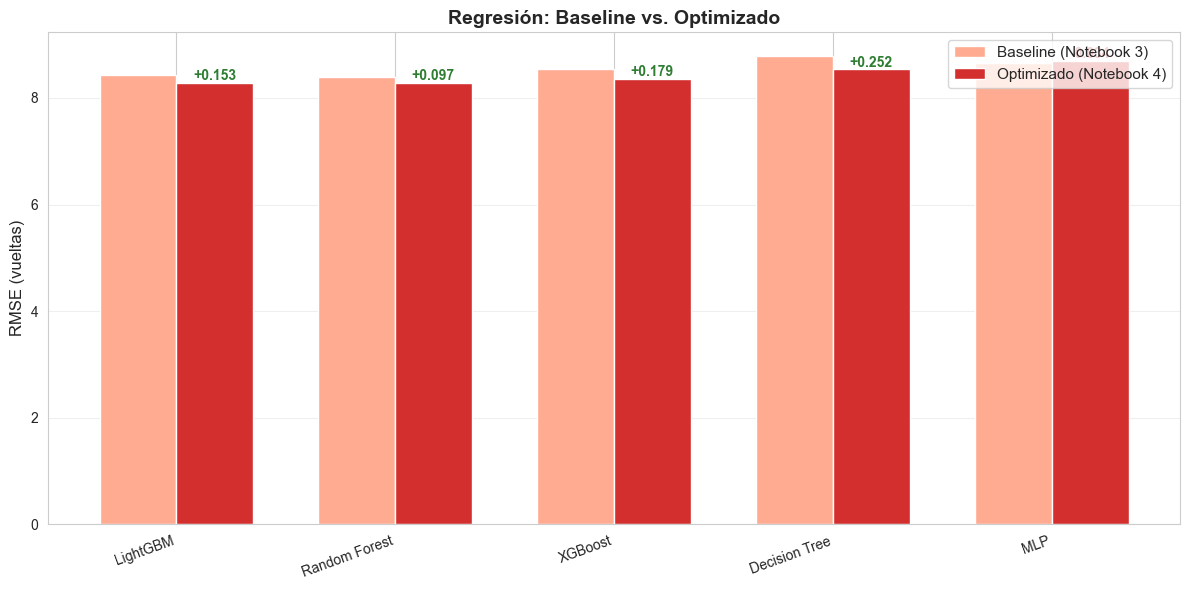

In [12]:
# ============================================================================
# GRÁFICO: BASELINE vs OPTIMIZADO — REGRESIÓN
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

modelos_r = df_opt_r.index.tolist()
x = np.arange(len(modelos_r))
width = 0.35

bars1 = ax.bar(x - width/2, df_opt_r['RMSE baseline'], width, label='Baseline (Notebook 3)',
               color='#FFAB91', edgecolor='white')
bars2 = ax.bar(x + width/2, df_opt_r['RMSE optimizado'], width, label='Optimizado (Notebook 4)',
               color='#D32F2F', edgecolor='white')

for i, (b, o, m) in enumerate(zip(df_opt_r['RMSE baseline'], df_opt_r['RMSE optimizado'], df_opt_r['Mejora RMSE'])):
    color = '#2E7D32' if m > 0 else '#C62828'
    ax.text(i + width/2, o + 0.05, f'{m:+.3f}', ha='center', fontsize=10,
            fontweight='bold', color=color)

ax.set_ylabel('RMSE (vueltas)', fontsize=12)
ax.set_title('Regresión: Baseline vs. Optimizado', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos_r, rotation=20, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./datasets/prepared/fig_baseline_vs_optimizado_regres.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Resumen global y mejores hiperparámetros

In [13]:
# ============================================================================
# RESUMEN FINAL
# ============================================================================

print('='*70)
print('RESUMEN — OPTIMIZACIÓN DE HIPERPARÁMETROS')
print('='*70)

print(f'\n📊 CLASIFICACIÓN')
print(f'{"─"*50}')
for nombre in df_opt_c.index:
    r = df_opt_c.loc[nombre]
    emoji = '📈' if r['Mejora'] > 0 else '➡️'
    print(f'  {emoji} {nombre:20s}  {r["F1 baseline"]:.4f} → {r["F1 optimizado"]:.4f} ({r["Mejora"]:+.4f})')

print(f'\n📈 REGRESIÓN')
print(f'{"─"*50}')
for nombre in df_opt_r.index:
    r = df_opt_r.loc[nombre]
    emoji = '📈' if r['Mejora RMSE'] > 0 else '➡️'
    print(f'  {emoji} {nombre:20s}  {r["RMSE baseline"]:.3f} → {r["RMSE optimizado"]:.3f} ({r["Mejora RMSE"]:+.3f})')

print(f'\n🏆 MEJORES MODELOS FINALES')
mejor_c = df_opt_c['F1 optimizado'].idxmax()
mejor_r = df_opt_r['RMSE optimizado'].idxmin()
print(f'  Clasificación: {mejor_c} (F1={df_opt_c.loc[mejor_c, "F1 optimizado"]:.4f})')
print(f'  Regresión:     {mejor_r} (RMSE={df_opt_r.loc[mejor_r, "RMSE optimizado"]:.3f})')

print(f'\n📋 MEJORES HIPERPARÁMETROS')
print(f'\n  {mejor_c} (clasificación):')
for k, v in mejores_clasif[mejor_c]['best_params'].items():
    print(f'    {k}: {v}')
print(f'\n  {mejor_r} (regresión):')
for k, v in mejores_regres[mejor_r]['best_params'].items():
    print(f'    {k}: {v}')

RESUMEN — OPTIMIZACIÓN DE HIPERPARÁMETROS

📊 CLASIFICACIÓN
──────────────────────────────────────────────────
  ➡️ MLP                   0.7111 → 0.6958 (-0.0153)
  ➡️ XGBoost               0.6874 → 0.6873 (-0.0001)
  ➡️ Random Forest         0.7006 → 0.6825 (-0.0181)
  📈 LightGBM              0.6558 → 0.6787 (+0.0229)
  📈 Decision Tree         0.5462 → 0.6438 (+0.0976)

📈 REGRESIÓN
──────────────────────────────────────────────────
  📈 LightGBM              8.437 → 8.284 (+0.153)
  📈 Random Forest         8.387 → 8.290 (+0.097)
  📈 XGBoost               8.542 → 8.363 (+0.179)
  📈 Decision Tree         8.792 → 8.540 (+0.252)
  ➡️ MLP                   8.658 → 8.692 (-0.034)

🏆 MEJORES MODELOS FINALES
  Clasificación: MLP (F1=0.6958)
  Regresión:     LightGBM (RMSE=8.284)

📋 MEJORES HIPERPARÁMETROS

  MLP (clasificación):
    activation: tanh
    alpha: 0.0062261634823634615
    hidden_layer_sizes: (64, 32)
    learning_rate_init: 0.003421940344785259
    max_iter: 300

  LightGBM (regr

## 7. Exportar resultados y modelos

In [14]:
# ============================================================================
# GUARDAR RESULTADOS Y MODELOS OPTIMIZADOS
# ============================================================================

# Tablas de resultados
df_opt_c.round(4).to_csv('./datasets/prepared/resultados_clasif_optimizado.csv')
df_opt_r.round(4).to_csv('./datasets/prepared/resultados_regres_optimizado.csv')

# Guardar mejores modelos
for nombre, info in mejores_clasif.items():
    with open(f'./datasets/prepared/modelo_clasif_{nombre.lower().replace(" ", "_")}.pkl', 'wb') as f:
        pickle.dump(info['best_model'], f)

for nombre, info in mejores_regres.items():
    with open(f'./datasets/prepared/modelo_regres_{nombre.lower().replace(" ", "_")}.pkl', 'wb') as f:
        pickle.dump(info['best_model'], f)

# Guardar hiperparámetros
hiperparams = {
    'clasificacion': {n: info['best_params'] for n, info in mejores_clasif.items()},
    'regresion': {n: info['best_params'] for n, info in mejores_regres.items()}
}

import json
# Convertir tipos numpy a nativos para JSON
def convert(obj):
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj

with open('./datasets/prepared/mejores_hiperparametros.json', 'w') as f:
    json.dump(hiperparams, f, indent=2, default=convert)

print('Archivos guardados:')
print('  ✓ resultados_clasif_optimizado.csv')
print('  ✓ resultados_regres_optimizado.csv')
print('  ✓ mejores_hiperparametros.json')
print('  ✓ modelo_clasif_*.pkl (5 modelos)')
print('  ✓ modelo_regres_*.pkl (5 modelos)')
print('  ✓ fig_baseline_vs_optimizado_clasif.png')
print('  ✓ fig_baseline_vs_optimizado_regres.png')
print('  ✓ fig_confusion_optimizado.png')

print(f'\n🎯 PRÓXIMOS PASOS:')
print(f'   1. Análisis SHAP para interpretabilidad')
print(f'   2. Añadir modelos adicionales (SVM, Logistic Regression)')
print(f'   3. Escribir Capítulos 4-7 del TFM')

Archivos guardados:
  ✓ resultados_clasif_optimizado.csv
  ✓ resultados_regres_optimizado.csv
  ✓ mejores_hiperparametros.json
  ✓ modelo_clasif_*.pkl (5 modelos)
  ✓ modelo_regres_*.pkl (5 modelos)
  ✓ fig_baseline_vs_optimizado_clasif.png
  ✓ fig_baseline_vs_optimizado_regres.png
  ✓ fig_confusion_optimizado.png

🎯 PRÓXIMOS PASOS:
   1. Análisis SHAP para interpretabilidad
   2. Añadir modelos adicionales (SVM, Logistic Regression)
   3. Escribir Capítulos 4-7 del TFM


---

**Fin del Notebook 4.** Los modelos optimizados están guardados en `./datasets/prepared/`
y listos para usar en análisis posteriores o en la redacción del TFM.